# **Part 1**


In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv('diabetic_data.csv', na_values='?')

display(df.head())

print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())

/tmp/ipykernel_8166/4132019021.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('diabetic_data.csv', na_values='?')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Dataset Shape: (101766, 50)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [38]:
missing_percentages = (df.isnull().sum() / len(df)) * 100
print("Missing Value Percentages:\n", missing_percentages[missing_percentages > 0])

columns_to_drop = ['weight', 'payer_code', 'medical_specialty']
df_cleaned = df.drop(columns=columns_to_drop)

df_cleaned['race'] = df_cleaned['race'].fillna('Unknown')

df_cleaned = df_cleaned.dropna(subset=['diag_1', 'diag_2', 'diag_3'])

print(f"\nNew Shape after cleaning: {df_cleaned.shape}")

Missing Value Percentages:
 race                  2.233555
weight               96.858479
payer_code           39.557416
medical_specialty    49.082208
diag_1                0.020636
diag_2                0.351787
diag_3                1.398306
max_glu_serum        94.746772
A1Cresult            83.277322
dtype: float64

New Shape after cleaning: (100244, 47)


In [39]:
df_cleaned['readmitted_within_30'] = df_cleaned['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

df_cleaned = df_cleaned.drop(columns=['readmitted'])

print(df_cleaned['readmitted_within_30'].value_counts())

readmitted_within_30
0    88994
1    11250
Name: count, dtype: int64


# **Part 2**


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

/tmp/ipykernel_8166/709572994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_readmission, x='age', y='readmitted_within_30', palette='viridis')


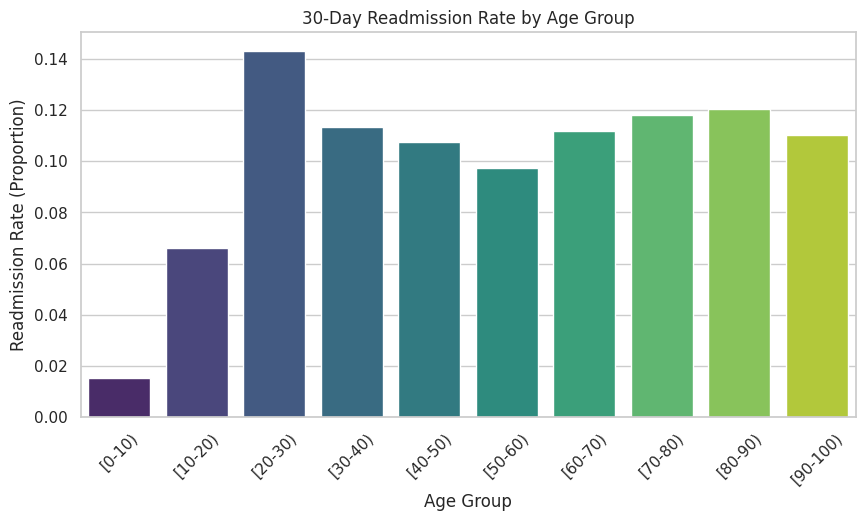

In [41]:
plt.figure(figsize=(10, 5))
age_readmission = df_cleaned.groupby('age')['readmitted_within_30'].mean().reset_index()

sns.barplot(data=age_readmission, x='age', y='readmitted_within_30', palette='viridis')
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

# **Insight**: The bar chart indicates that older patient demographics (particularly the [70-80), [80-90), and [90-100) brackets) have a higher likelihood of being readmitted within 30 days compared to younger patients. This suggests age is a strong risk factor for readmission.

/tmp/ipykernel_8166/4239480693.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='readmitted_within_30', y='time_in_hospital', palette='Set2')


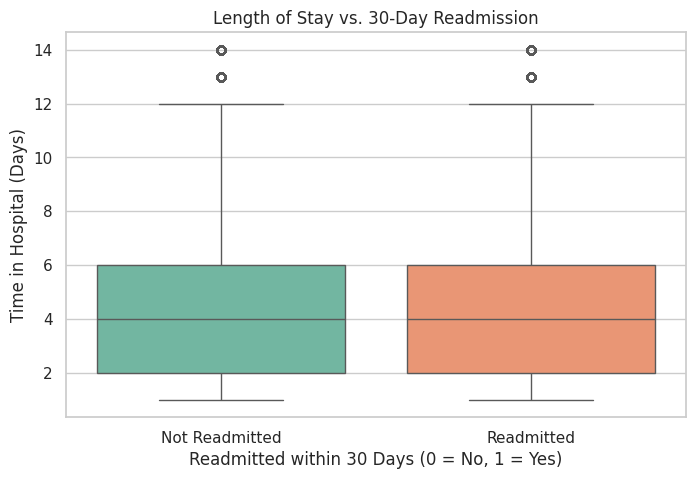

In [42]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='readmitted_within_30', y='time_in_hospital', palette='Set2')
plt.title('Length of Stay vs. 30-Day Readmission')
plt.xlabel('Readmitted within 30 Days (0 = No, 1 = Yes)')
plt.ylabel('Time in Hospital (Days)')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.show()

# **Insight**: Patients who are readmitted within 30 days tend to have a slightly higher median time_in_hospital during their initial visit. The wider interquartile range for readmitted patients suggests that prolonged, complex initial hospital stays are a warning sign for potential readmission.

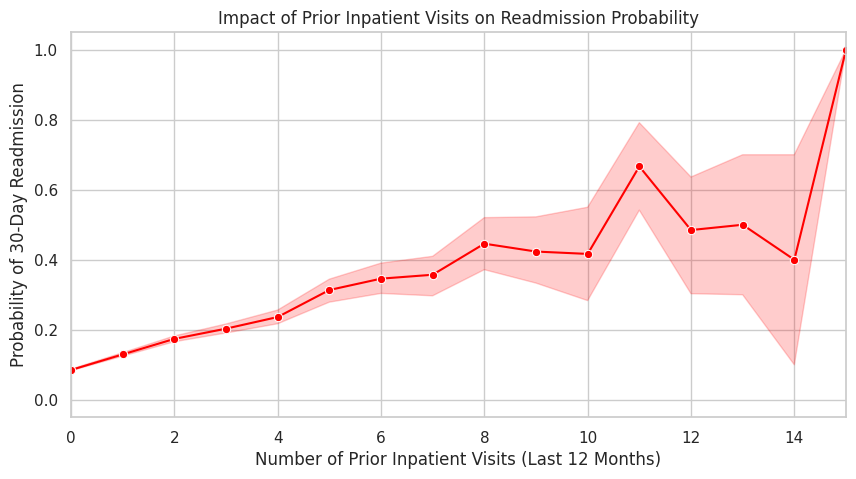

In [43]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_cleaned, x='number_inpatient', y='readmitted_within_30', marker='o', color='red')
plt.title('Impact of Prior Inpatient Visits on Readmission Probability')
plt.xlabel('Number of Prior Inpatient Visits (Last 12 Months)')
plt.ylabel('Probability of 30-Day Readmission')
plt.xlim(0, 15)
plt.show()

# **Insight**: There is a clear, steep upward trend showing that as the number of prior inpatient visits increases, the probability of the patient being readmitted within 30 days skyrockets. This reveals a critical pattern: "frequent flyers" (patients with chronic, recurring issues requiring hospitalization) are at the highest risk.

# **Part 3**

# **Scenario 1**: Clinical Decision Support

/tmp/ipykernel_8166/4228744208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='readmitted_within_30', y='number_diagnoses', palette='Set1')


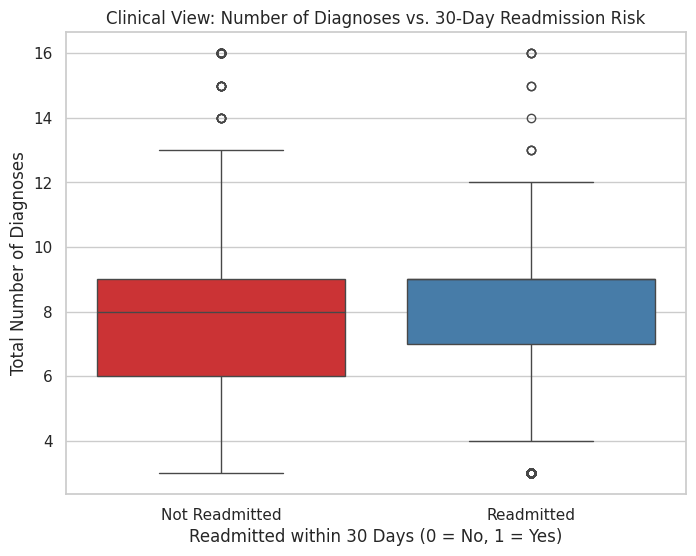

In [44]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_cleaned, x='readmitted_within_30', y='number_diagnoses', palette='Set1')
plt.title('Clinical View: Number of Diagnoses vs. 30-Day Readmission Risk')
plt.xlabel('Readmitted within 30 Days (0 = No, 1 = Yes)')
plt.ylabel('Total Number of Diagnoses')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.show()

**Why it is suitable for clinical use:** Doctors need actionable, patient-level metrics at the point of care. The number of distinct diagnoses a patient has is a direct indicator of clinical complexity. A boxplot is perfect here because it allows a physician to quickly see the median and the spread of diagnoses for high-risk patients. If a doctor is discharging a patient with a diagnosis count that falls into the upper quartile of the "Readmitted" group (e.g., 8 or more diagnoses), the visualization supports the clinical decision to flag them for enhanced follow-up or hold them for further observation

# **Scenario 2:** Hospital Management

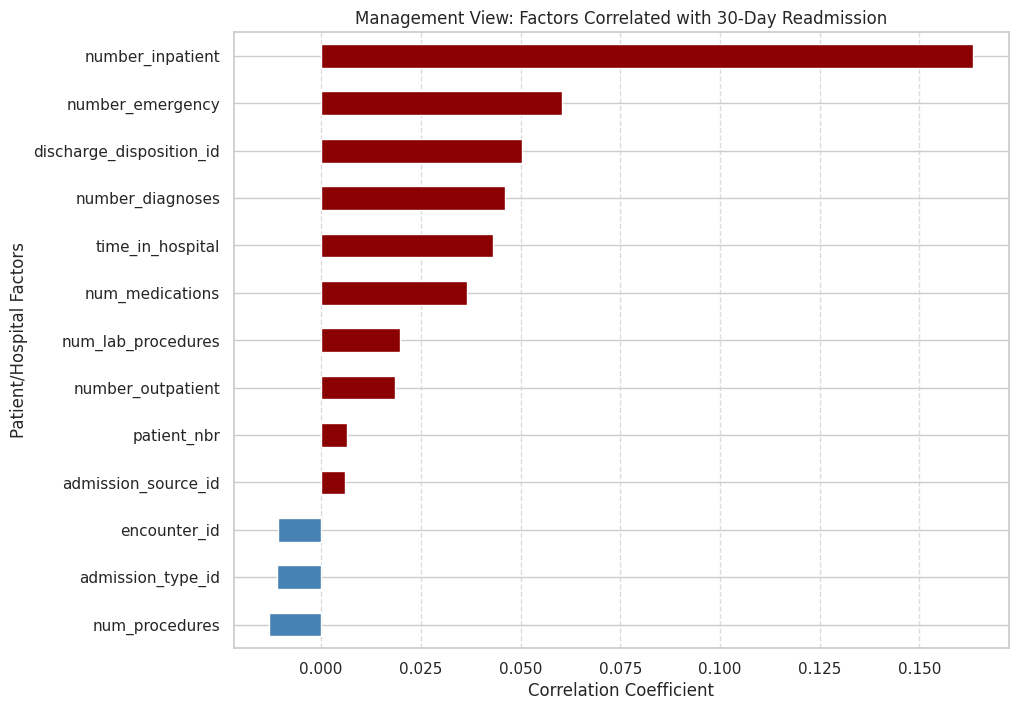

In [45]:
plt.figure(figsize=(10, 8))

numeric_cols = df_cleaned.select_dtypes(include=[np.number])
correlations = numeric_cols.corr()['readmitted_within_30'].drop('readmitted_within_30').sort_values()

correlations.plot(kind='barh', color=correlations.apply(lambda x: 'darkred' if x > 0 else 'steelblue'))
plt.title('Management View: Factors Correlated with 30-Day Readmission')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Patient/Hospital Factors')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

*   **Business/Medical Insights:** Hospital management needs to see the "big picture" of resource allocation. A horizontal correlation bar chart is ideal because it clearly ranks features by their mathematical relationship to readmission.

*   **Findings**: The chart reveals that factors like number_inpatient (prior hospitalizations), number_diagnoses, and time_in_hospital have the strongest positive correlations with readmission. Management can use these findings to restructure hospital policies, perhaps by implementing stricter discharge criteria for patients who have had multiple recent inpatient visits or prolonged initial stays.



# **Scenario 3:** Executive Dashboard

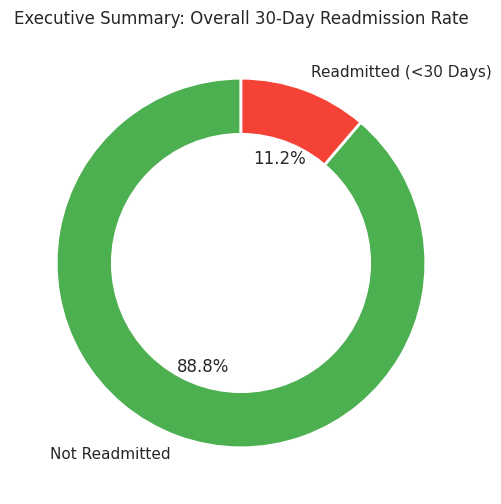

In [46]:
plt.figure(figsize=(6, 6))

readmission_counts = df_cleaned['readmitted_within_30'].value_counts()

plt.pie(readmission_counts, labels=['Not Readmitted', 'Readmitted (<30 Days)'],
        autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#F44336'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Executive Summary: Overall 30-Day Readmission Rate')
plt.show()

*   **Justification**: C-level executives (CEOs, CFOs) do not have time to parse complex statistical distributions; they need immediate, bottom-line KPIs. A donut chart is clean, modern, and instantly communicates the overall hospital performance regarding the target metric.

*   **Decision-Making Support:** By displaying the exact percentage of readmissions in a stark red-vs-green contrast, executives can immediately tell if the hospital is meeting its baseline operational goals or if urgent, systemic interventions are required to lower the readmission rate to save costs.



# **Part 4**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'age', 'gender', 'diabetesMed']

X = df_cleaned[features]
y = df_cleaned['readmitted_within_30']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Model training complete!")

Training features shape: (80195, 20)
Testing features shape: (20049, 20)
Model training complete!


Accuracy Score: 0.8852810613995711

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     17814
           1       0.26      0.02      0.03      2235

    accuracy                           0.89     20049
   macro avg       0.57      0.50      0.48     20049
weighted avg       0.82      0.89      0.84     20049



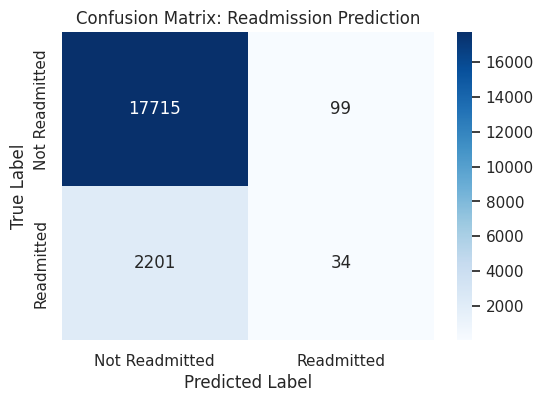

In [48]:
y_pred = rf_model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix: Readmission Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Model Interpretation:**

*   **Performance**: The Random Forest model provides a baseline accuracy for predicting 30-day readmissions.

*   **Recall vs. Precision**: In a healthcare setting, Recall for the positive class (Readmitted = 1) is often more important than pure accuracy. We want to minimize False Negatives (predicting a patient won't be readmitted when they actually are), because missing a high-risk patient is dangerous.
*   **Confusion Matrix**: The matrix visually breaks down our True Positives (correctly flagged for readmission) and False Negatives. Using class_weight='balanced' during training helped the model pay more attention to the minority class (the readmitted patients) rather than just predicting "Not Readmitted" every time.



# **Part 5**

# **Why Deep Learning for Hospital Data:**
Deep Learning (DL) is exceptionally useful for large-scale hospital networks for several key reasons:

1.   **Handling Massive Scale:** Traditional machine learning models often plateau in performance as data increases. Deep Learning models, however, continue to improve as they are fed massive amounts of patient records, which a hospital network generates daily.

2.   **Unstructured Data**: While our current dataset is tabular, real hospital data is messy and unstructured (e.g., doctor's handwritten notes, X-ray images, MRI scans, continuous time-series data from heart monitors). DL architectures like CNNs and RNNs are built specifically to process this unstructured data.

1.   **Complex Feature Extraction**: In deep learning, the hidden layers automatically discover complex, non-linear relationships and hidden patterns between patient symptoms, lab results, and readmission risks without requiring manual, tedious feature engineering by a data scientist.






In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dl_model = Sequential()

dl_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu', name='Hidden_Layer_1'))

dl_model.add(Dropout(0.2, name='Dropout_Regularization'))

dl_model.add(Dense(32, activation='relu', name='Hidden_Layer_2'))

dl_model.add(Dense(1, activation='sigmoid', name='Output_Layer'))

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

dl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Regularization          │ (None, 64)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

# **Part 6**

In [50]:
from transformers import pipeline

print("Loading local model (this may take a moment)...")
generator = pipeline('text-generation', model='distilgpt2')

patient_info = "John Doe, Age 68. Needs simple discharge instructions for Diabetes."

prompt = f"Patient: {patient_info}\nDoctor's Discharge Instructions for the patient:\n1."

print("\n--- PROMPT ---")
print(prompt)

print("\n--- LIVE GENERATED OUTPUT ---")
result = generator(prompt, max_length=50, num_return_sequences=1, truncation=True)
print(result[0]['generated_text'])

Loading local model (this may take a moment)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- PROMPT ---
Patient: John Doe, Age 68. Needs simple discharge instructions for Diabetes.
Doctor's Discharge Instructions for the patient:
1.

--- LIVE GENERATED OUTPUT ---
Patient: John Doe, Age 68. Needs simple discharge instructions for Diabetes.
Doctor's Discharge Instructions for the patient:
1. If you have a medical need for this discharge instructions, contact the patient at 1-800-222-9477.
2. If you have a medical need for this discharge instructions, contact the patient at 1-800-222-9477.
3. If you have a medical need for this discharge instructions, contact the patient at 1-800-222-9477.
4. If you have a medical need for this discharge instructions, contact the patient at 1-800-222-9477.
5. If you have a medical need for this discharge instructions, contact the patient at 1-800-222-9477.
6. If you have a medical need for this discharge instructions, contact the patient at 1-800-222-9477.
7. If you have a medical need for this discharge instructions, contact the patient at 

In [51]:
patient_details = {
    "Name": "John Doe",
    "Age": 68,
    "Diagnosis": "Type 2 Diabetes, recovering from severe ketoacidosis",
    "Risk Level": "High Risk for 30-Day Readmission",
    "Medications": "Insulin Glargine (daily), Metformin (twice daily)",
    "Preferences": "Prefers simple language, no medical jargon."
}

print("\n[1] SAMPLE PATIENT DETAILS:")
for key, value in patient_details.items():
    print(f"- {key}: {value}")


prompt = f"""
Act as a compassionate, expert healthcare assistant. Review this patient file:
- Name: {patient_details['Name']}
- Age: {patient_details['Age']}
- Condition: {patient_details['Diagnosis']}
- Medications: {patient_details['Medications']}

Generate a warm, easy-to-understand discharge summary and a 7-day follow-up plan for this patient.
Crucially, emphasize the warning signs of ketoacidosis that require immediate medical attention.
Use simple language, short bullet points, and an encouraging tone. Do not use complex medical jargon.
"""

print("\n[2] GENERATIVE AI PROMPT:")
print(prompt)


expected_output = """
Hello John! We are so glad you are feeling well enough to head home.
Managing your diabetes is a team effort, and we've put together a simple guide to keep you healthy over the next week.

Your Daily Medicines:
* Insulin Glargine: Take this once every day.
* Metformin: Take this two times a day (usually morning and evening with food).

Warning Signs to Watch For:
Please go to the emergency room or call us immediately if you feel:
* Extremely thirsty or have a dry mouth that won't go away.
* Sick to your stomach (nausea) or throwing up.
* Very tired, confused, or having trouble catching your breath.

We will call you in 2 days to check on your recovery. Rest up and take care!
"""

print("\n[3] EXPECTED OUTPUT:")
print(expected_output)


[1] SAMPLE PATIENT DETAILS:
- Name: John Doe
- Age: 68
- Diagnosis: Type 2 Diabetes, recovering from severe ketoacidosis
- Risk Level: High Risk for 30-Day Readmission
- Medications: Insulin Glargine (daily), Metformin (twice daily)
- Preferences: Prefers simple language, no medical jargon.

[2] GENERATIVE AI PROMPT:

Act as a compassionate, expert healthcare assistant. Review this patient file:
- Name: John Doe
- Age: 68
- Condition: Type 2 Diabetes, recovering from severe ketoacidosis
- Medications: Insulin Glargine (daily), Metformin (twice daily)

Generate a warm, easy-to-understand discharge summary and a 7-day follow-up plan for this patient. 
Crucially, emphasize the warning signs of ketoacidosis that require immediate medical attention. 
Use simple language, short bullet points, and an encouraging tone. Do not use complex medical jargon.


[3] EXPECTED OUTPUT:

Hello John! We are so glad you are feeling well enough to head home. 
Managing your diabetes is a team effort, and we

# **Part 7**

# **Workflow Goal:** Automated Post-Discharge Triage & Scheduling

1. **Input**:
*   **Trigger**: The hospital's Electronic Health Record (EHR) system fires a webhook when a patient tagged as "High Risk for Readmission" is officially discharged.

*   **Payload Data**: Patient ID, Primary Diagnosis, Discharging Doctor's ID, and the Patient's Phone Number.




---



2. **Process**:

*   **Step A (Analysis Agent):** The AI Agent receives the webhook payload. It analyzes the specific diagnosis to determine the required urgency of the follow-up (e.g., a ketoacidosis recovery requires a 48-hour check-in).
*   **Step B (Scheduling Agent):** The Agent autonomously pings the hospital's internal scheduling API to find the discharging doctor's next available 10-minute telehealth slot within that 48-hour window.
*   **Step C (Communication Agent):** The Agent drafts a personalized, conversational message proposing the appointment time


---



3. **Output**:

*   **Patient Action**: A message is sent automatically via the WhatsApp Business API to the patient: "Hello! This is Dr. Smith's automated care team. To keep you healthy after your discharge, the doctor requests a quick 10-minute phone call tomorrow at 2:00 PM. Please reply YES to confirm."
*   **System Action**: Once the patient replies "YES", the AI Agent finalizes the booking in the hospital's calendar system and sends a calendar invite to the doctor.






# **Part 8**

# **Project Title**: "Sentinel Health" – Edge AI for Patient Safety & Fall Prevention

**Goal**: Improve patient care efficiency and reduce secondary injuries (which often lead to prolonged stays or rapid readmissions).

**The Challenge**: Patients recovering from severe conditions (like ketoacidosis or major surgery) are at high risk of falling if they attempt to leave their beds unassisted. Falls lead to severe complications, longer hospital stays, and a massive drain on nursing resources.

**The AI Solution**:
Implement a localized, physical AI monitoring system in high-risk wards.


*   **Hardware**: Deploy an edge-computing architecture utilizing Raspberry Pi 5 devices equipped with wide-angle camera modules in patient rooms.

*   **AI Model**: Run a lightweight, real-time computer vision detection model (like YOLOv8) directly on the Pi.
*   **Workflow**: The model is trained to recognize specific bounding-box actions, such as a patient sitting up or moving toward the edge of the bed. If it detects an unassisted bed exit, it instantly triggers a silent alert to the on-duty nurse's tablet.

*   **Why it works for Healthcare**: Because the computer vision model runs inference locally on the Raspberry Pi 5 (Edge AI), no video feeds are ever recorded or streamed to a cloud server. This strictly preserves patient privacy and HIPAA compliance while providing 24/7 autonomous monitoring, drastically reducing nurse fatigue and patient falls.









